# Import utils

In [1]:
from utils.classification_utils import ClassifierPreprocessor
from utils.dataset_utils import SegmentDatasetAllTimestamps

# Create my own classifier class

In [2]:
classifier_preprocessor = ClassifierPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", annotation_json="../../../../data/ml/machine-and-movement_complete.json")

# Read and Preprocess for training

In [3]:
sensors_df, annotation_dict = classifier_preprocessor.read_data()
sensors_df = classifier_preprocessor.feature_selection()
sensors_df = classifier_preprocessor.assign_labels()
sensors_df = classifier_preprocessor.normalize_and_encode_labels()

# Create the Dataloader

In [4]:
from torch.utils.data import DataLoader
batch_size = 64
train_df, val_df, test_df, experiment_ids = classifier_preprocessor.split_experiments()
train_dataset, val_dataset, test_dataset = classifier_preprocessor.create_datasets(
    train_df, val_df, test_df, SegmentDatasetAllTimestamps
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Total experiments: 315
Train experiments: 221
Val experiments: 63
Test experiments: 31


# Create the model and train

In [5]:
feature_cols = classifier_preprocessor.get_feature_cols()
input_size = len(feature_cols)
hidden_size = 64
num_layers = 2
num_classes = len(train_dataset.unique_labels)

In [6]:
import torch
from utils.model import LSTMClassifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes, bidirectonal=True).to(device)

In [7]:
model_path = "../../../../models/classifier/machine_and_movement"

In [8]:
# model.train_model(
#     train_loader=train_loader,
#     val_loader=val_loader,
#     num_epochs=100,
#     learning_rate=1e-5,
#     patience=3,
#     device=device,
#     model_path="../../../../models/classifier/machine_and_movement"
# )

# Load and Evaluate the Model

In [9]:
import joblib

# load state_dict via joblib
state_dict = joblib.load(f"{model_path}/Activity_Detector.joblib")
model.load_state_dict(state_dict)
model.eval()

LSTMClassifier(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)

# Vizualize the Prediction

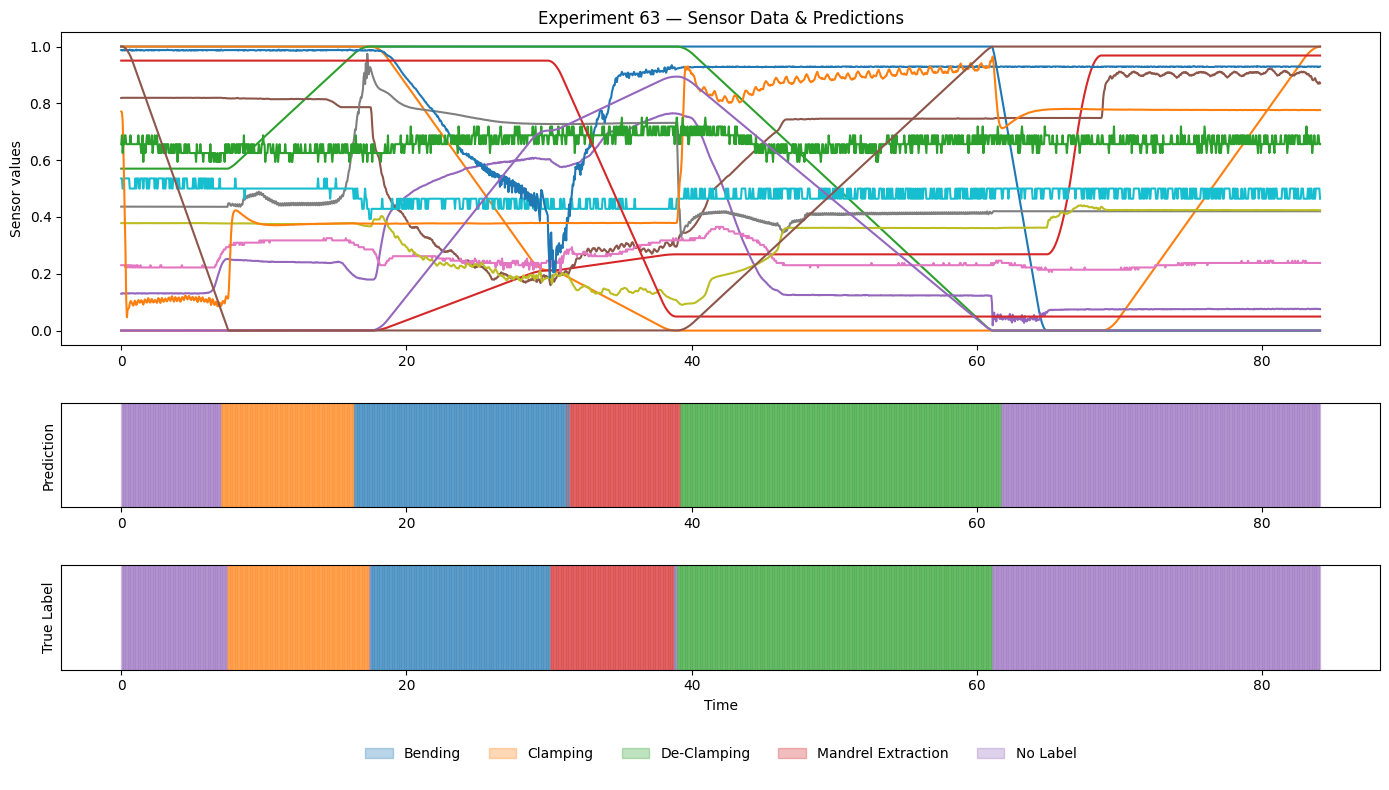

In [10]:
from utils.plot_utils import plot_predictions_vs_true_annot
plot_predictions_vs_true_annot(model, test_dataset, sensors_df, feature_cols, experiment_ids)

In [11]:
df = sensors_df[(sensors_df["Label"] == "Bending") | (sensors_df["Label"] == "Mandrel Extraction")].drop(columns=["Label_encoded", "Label"])
df.to_csv("bending_features.csv")
df = sensors_df[(sensors_df["Label"] == "Clamping")].drop(columns=["Label_encoded", "Label"])
df.to_csv("clamping_features_features.csv")